# ***Explicabilidad (XAI)***

En este apartado abordamos la problemática de la **explicabilidad** (*Explainable AI, XAI*). Esta problemática es especialmente relevante en este contexto por dos motivos:

- **Ético y legal**: el modelo toma decisiones que afectan directamente a pacientes. El personal médico necesita entender por qué el modelo predice un alto riesgo de readmisión para poder actuar en consecuencia.
- **Clínico**: las predicciones solo son útiles si se apoyan en variables médicamente razonables. Un modelo que predice correctamente pero por razones equivocadas (por ejemplo, apoyándose en la raza del paciente en lugar de en su historial clínico) no puede desplegarse con confianza en un entorno hospitalario real.

Se aplicarán dos técnicas complementarias de explicabilidad:
1. **SHAP** (*SHapley Additive exPlanations*): explicaciones globales y locales basadas en teoría de juegos cooperativos. Garantiza consistencia matemática y permite comparar la influencia de cada variable a nivel de todo el dataset o de una instancia concreta.
2. **LIME** (*Local Interpretable Model-agnostic Explanations*): explicaciones locales mediante un modelo lineal aproximado en el entorno de cada instancia. Es agnóstico al modelo y permite inspeccionar casos individuales de forma intuitiva.

El modelo base utilizado es **XGBoost**, ya que fue seleccionado como el clasificador con mejor rendimiento en la comparativa de modelos del proyecto. Al final de la sección se incluye además una **comparativa empírica** entre el modelo con y sin atributos sensibles (`race`, `gender`, `age`), con el fin de evaluar si su eliminación del pipeline es viable sin degradar el rendimiento.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score 
import shap
import numpy as np
import matplotlib.patches as mpatches
from xgboost import XGBClassifier
from lime.lime_tabular import LimeTabularExplainer
from matplotlib.colors import ListedColormap

In [3]:
SEED = 22
np.random.seed(SEED)

Para garantizar coherencia con el resto del proyecto, se parte del mismo dataset preprocesado (`diabetes_preprocesado.csv`) y se aplica la misma semilla de aleatoriedad (`SEED = 22`) y estrategia de división estratificada que en los demás notebooks. Se eliminan los identificadores de paciente (`encounter_id`, `patient_nbr`) por no aportar capacidad predictiva y para proteger la privacidad de los individuos.

El objetivo aquí es entender el comportamiento interno del modelo tal y como se entrena en su versión baseline, sin intervenciones adicionales que puedan enmascarar su lógica de decisión.

In [4]:
df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=",", quotechar='"')

cols_to_drop = ['encounter_id', 'patient_nbr']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

y = df["readmitted"]
X = df.drop(columns=["readmitted"])

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=SEED,
        stratify=y
    )

colors = ['#F7A8B8', '#CDB4DB', '#A2D2FF']  # rosa, lila, azul pastel

Una vez cargados los datos, se verifica la distribución de clases y el tamaño del dataset para contextualizar los análisis posteriores. El dataset presenta un fuerte desbalanceo entre clases: la clase mayoritaria (`No readmitido`, clase 0) concentra más de la mitad de los registros, mientras que la clase crítica de interés clínico (`Readmisión <30 días`, clase 2) representa tan solo una fracción minoritaria del total. Esta asimetría tiene implicaciones directas en los valores SHAP, ya que el modelo tenderá a priorizar la discriminación de la clase dominante, lo que debe tenerse en cuenta al interpretar la importancia relativa de las *features*.

In [5]:
feature_names = list(X.columns)

print(f'Dataset: {X.shape[0]} instancias, {X.shape[1]} features')
print(f'\nDistribución de clases:')
print(y.value_counts().rename({0: 'No readmitido', 1: '>30 días', 2: '<30 días'}))

Dataset: 98053 instancias, 43 features

Distribución de clases:
readmitted
No readmitido    52338
>30 días         34649
<30 días         11066
Name: count, dtype: int64


La partición **80/20** en entrenamiento y test, con estratificación sobre la variable objetivo, garantiza que la distribución de clases se preserva proporcionalmente en ambos subconjuntos. Esto es especialmente relevante para la clase minoritaria (clase 2), donde una división no estratificada podría generar variaciones significativas en su representación y distorsionar tanto el entrenamiento del modelo como la evaluación de las explicaciones SHAP y LIME sobre el conjunto de test.

In [6]:
print(f'Entrenamiento: {X_train.shape[0]} instancias')
print(f'Test:          {X_test.shape[0]} instancias')

Entrenamiento: 78442 instancias
Test:          19611 instancias


## 1. Entrenamiento del modelo (XGBoost)

Se entrena el clasificador **XGBoost** directamente sobre los datos de entrenamiento sin balanceo previo, con la misma configuración de hiperparámetros empleada en la selección del baseline del proyecto. El conjunto de test permanece intacto en su distribución natural para que las métricas reflejen fielmente el comportamiento del modelo sobre datos reales.

Aunque en el notebook de desbalanceo se exploró SMOTE como técnica de sobremuestreo, en este contexto de explicabilidad se entrena sin esta corrección para mantener la transparencia del pipeline. Aplicar SMOTE generaría instancias sintéticas en el entrenamiento que no corresponden a pacientes reales, lo que podría introducir artefactos en las explicaciones SHAP al calcular los *Shapley values* sobre distribuciones artificiales. El objetivo aquí no es maximizar el rendimiento sobre la clase minoritaria, sino **comprender la lógica interna del modelo** sobre datos representativos de la realidad hospitalaria.

In [7]:
# El modelo para XAI se entrena sobre los datos ya balanceados con SMOTE
# (X_train_smote, y_train_smote definidos en la sección 1 del notebook)
# Esto es coherente con el pipeline general del proyecto.

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.2,
    subsample=0.8,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print('Rendimiento del modelo XGBoost entrenado con SMOTE (conjunto de test):')
print(classification_report(
    y_test, y_pred,
    target_names=['No readmitido (0)', '>30 días (1)', '<30 días (2)']
))
print(f'F1-macro: {f1_score(y_test, y_pred, average="macro"):.4f}')

Rendimiento del modelo XGBoost entrenado con SMOTE (conjunto de test):
                   precision    recall  f1-score   support

No readmitido (0)       0.62      0.82      0.71     10468
     >30 días (1)       0.50      0.40      0.45      6930
     <30 días (2)       0.42      0.04      0.07      2213

         accuracy                           0.58     19611
        macro avg       0.51      0.42      0.41     19611
     weighted avg       0.56      0.58      0.54     19611

F1-macro: 0.4087


El *classification report* permite leer el rendimiento del modelo clase a clase y detectar si las métricas globales ocultan comportamientos asimétricos. En un problema con desbalanceo tan pronunciado como este, el *Accuracy* global puede resultar engañosamente alto: un clasificador trivial que siempre predicha la clase mayoritaria obtendría un *Accuracy* superior al 50% sin ningún valor clínico.

Por ello, el **F1-macro** actúa como el indicador de rendimiento principal, ya que pondera las tres clases por igual independientemente de su soporte. El **F1-score específico de la clase 2** (readmisión en menos de 30 días) es la métrica más exigente y clínicamente relevante: mide la capacidad real del modelo para detectar los casos de mayor urgencia. Unos valores bajos en este indicador son esperables dada la escasez de ejemplos positivos en el dataset, pero no invalidan el análisis de explicabilidad posterior, al contrario, resulta especialmente valioso identificar *qué variables* llevan al modelo a sus aciertos y a sus errores sobre esta clase crítica.

## 2. Explicabilidad global con SHAP

SHAP (*SHapley Additive exPlanations*) es actualmente el estándar de facto para la explicabilidad de modelos de *machine learning*. Se fundamenta en la teoría de juegos cooperativos: para cada instancia, calcula la contribución marginal promedio de cada *feature* a la predicción final, considerando todas las posibles combinaciones del resto de variables. Esto garantiza propiedades matemáticas deseables como **consistencia**, **eficiencia** (la suma de todos los SHAP values siempre es igual a la diferencia entre la predicción y el valor esperado del modelo) y **simetría**.

Para modelos basados en árboles de decisión como XGBoost, la variante `TreeExplainer` calcula los *Shapley values* de forma exacta y eficiente, sin necesidad de aproximaciones por muestreo.

Dado que el problema es **multiclase** (3 categorías), SHAP genera un vector de valores por instancia y por clase. El análisis se centra principalmente en la **clase 2** (readmisión en menos de 30 días), que representa el evento clínico de mayor urgencia y menor representación en los datos.

In [8]:
explainer = shap.TreeExplainer(xgb_model)

# Calculamos SHAP values sobre el conjunto de test completo
shap_values = explainer.shap_values(X_test)

print(f'Tipo de shap_values: {type(shap_values)}')
if isinstance(shap_values, list):
    print(f'Número de clases: {len(shap_values)}')
    print(f'Shape por clase: {shap_values[0].shape}')
else:
    print(f'Shape: {shap_values.shape}')

Tipo de shap_values: <class 'list'>
Número de clases: 3
Shape por clase: (19611, 43)


Una vez calculados los *Shapley values* sobre el conjunto de test completo, se generan tres tipos de visualizaciones globales complementarias para obtener una imagen completa de la lógica del modelo: el **bar plot agregado por clase**, el **beeswarm plot** centrado en la clase crítica y los **dependence plots** de las *features* más influyentes.

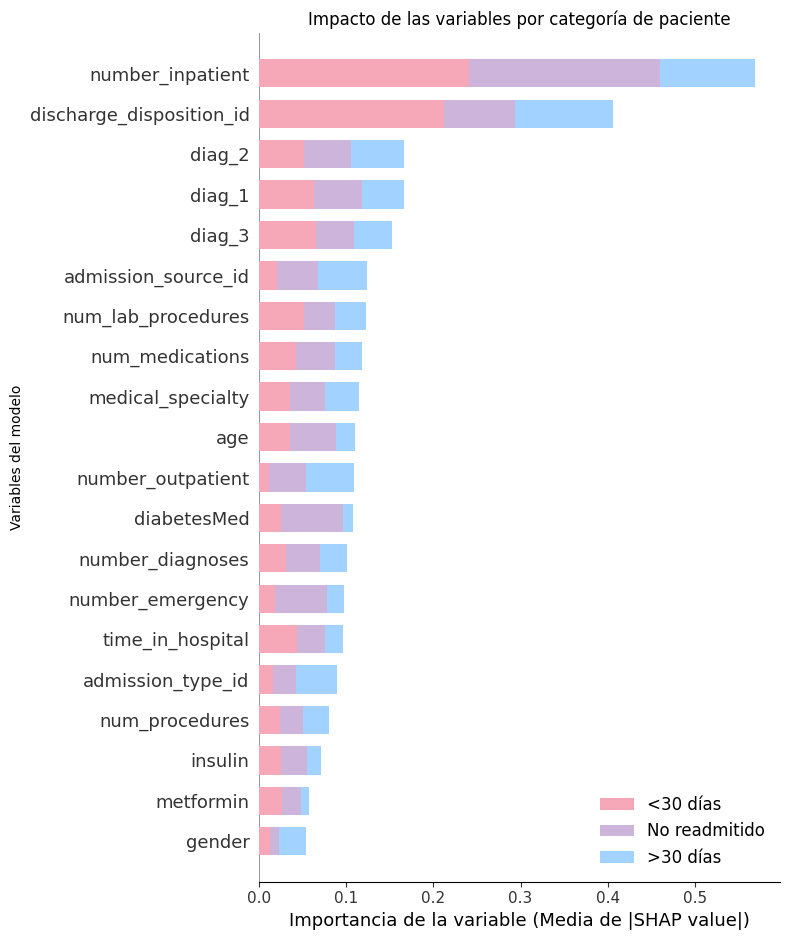

In [9]:
mapa = ListedColormap(colors) # Usamos el mapa de colores para evitar el TypeError

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar",
    color=mapa,  
    class_names=['No readmitido', '>30 días', '<30 días'],
    show=False      # Permitimos modificaciones posteriores
)

plt.xlabel("Importancia de la variable (Media de |SHAP value|)") 
plt.ylabel("Variables del modelo")
plt.title("Impacto de las variables por categoría de paciente")

plt.tight_layout()
plt.savefig("../visualizacion_problematicas/shap_bar.png")
plt.show()

El *bar plot* agrupado por clase revela cuáles son las *features* que más contribuyen al proceso de decisión del modelo en cada uno de los tres escenarios de readmisión. Las barras representan la importancia media del valor absoluto de los SHAP values, lo que permite identificar qué variables tienen mayor influencia independientemente de la dirección de su efecto.

Al examinar el gráfico de importancia basado en los valores SHAP, se observa que las variables con mayor impacto predictivo global corresponden a **indicadores clínicos estructurales y del historial médico del paciente**, liderados de forma masiva por el número de ingresos previos (`number_inpatient`) y el identificador de alta médica (`discharge_disposition_id`), seguidos por el desglose de códigos diagnósticos principales (`diag_2`, `diag_1` y `diag_3`). Este patrón posee una alta coherencia médica, ya que la recurrencia en hospitalizaciones previas y el tipo de alta (por ejemplo, si el paciente fue trasladado a cuidados domiciliarios o a otra institución) constituyen los factores clínicos más complejos y determinantes para evaluar el riesgo de inestabilidad y complicaciones metabólicas severas.

Resulta igualmente relevante observar la **distribución diferencial de la importancia entre las categorías de pacientes**. En las variables dominantes como el historial de ingresos y la disposición de alta, el peso se distribuye de manera significativa entre las tres clases, mostrando una marcada influencia en la predicción de readmisiones en menos de 30 días (barras rosas). No obstante, al descender en el gráfico hacia variables como la edad (`age`), el tiempo de hospitalización (`time_in_hospital`) o el uso de medicamentos como la insulina y la metformina, se aprecia que su contribución se concentra principalmente en clasificar a los pacientes estables (categoría de no readmitido, barras moradas) y a aquellos con reingresos tardíos (barras azules). Este comportamiento refleja que el modelo no aísla las fronteras de decisión, sino que modula el significado de las mismas señales de tratamiento y características demográficas según la ventana temporal del reingreso del paciente.

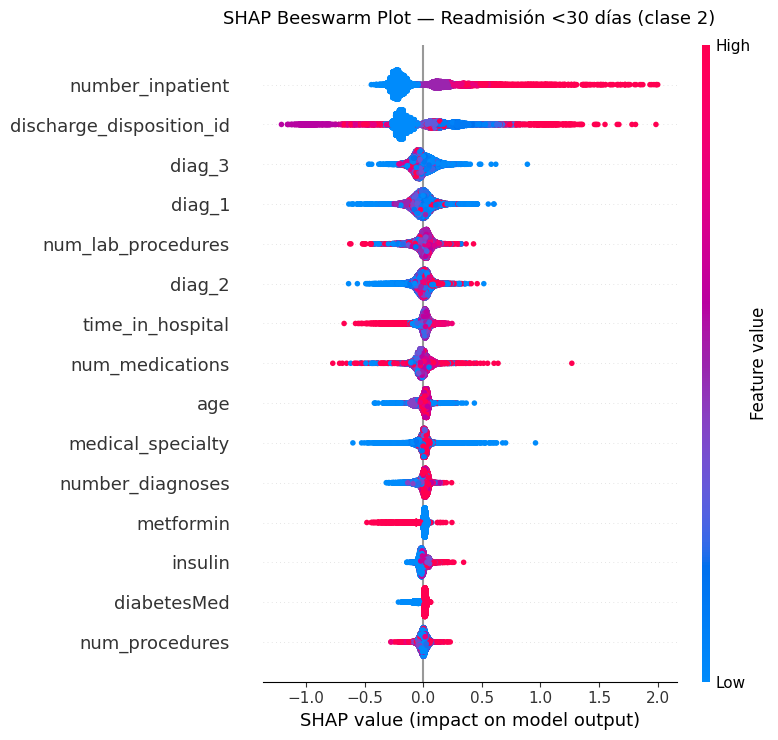

In [10]:
# --- BEESWARM PLOT (Summary Plot): importancia global + dirección del efecto ---
# Mostramos las top 15 features más importantes para predecir readmisión <30 días (clase 2)

# Índice de la clase de interés clínico: readmisión temprana
CLASS_IDX = 2
CLASS_NAME = 'Readmisión <30 días (clase 2)'

if isinstance(shap_values, list):
    sv_class = shap_values[CLASS_IDX]
else:
    sv_class = shap_values[:, :, CLASS_IDX]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv_class,
    X_test,
    feature_names=feature_names,
    max_display=15,
    show=False,
    plot_type='dot'   # beeswarm
)
plt.title(f'SHAP Beeswarm Plot — {CLASS_NAME}', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/shap_beeswarm_clase2.png', dpi=150, bbox_inches='tight')
plt.show()

El *beeswarm plot* (o *summary plot*) de SHAP para la clase 2 aporta una dimensión adicional de información que el bar plot no puede mostrar: la **dirección del efecto** de cada *feature* sobre la probabilidad de readmisión temprana. Cada punto representa una instancia del conjunto de test, coloreada según el valor real de la variable (rojo = valor alto, azul = valor bajo), y su posición horizontal refleja la magnitud y el signo de su contribución SHAP.

Al interpretar el gráfico *SHAP Beeswarm*, se pueden extraer patrones clínicos de alta relevancia para la detección de la clase crítica (`Readmitido <30 días`). Los puntos rojos (valores altos) de la variable `number_inpatient` concentrados de forma masiva en la zona de SHAP positivo indican que un mayor historial de ingresos previos empuja drásticamente la predicción hacia la alerta de readmisión temprana. En el caso de `discharge_disposition_id`, se observa una dispersión mixta donde ciertos tipos de alta médica (puntos rojos) generan un fuerte impacto positivo en el riesgo, mientras que otros disminuyen notablemente la probabilidad estimada. Por su parte, los diagnósticos secundarios y principales (`diag_3`, `diag_1` y `diag_2`) muestran una acumulación densa en torno al valor cero, pero con colas de puntos azules y rojos que extienden su influencia a ambos lados del eje, reflejando cómo la codificación de patologías específicas altera el juicio del modelo.

En sentido contrario, variables de tratamiento farmacológico directo como `metformin` presentan una acumulación de valores altos (puntos rojos) desplazados hacia la zona de SHAP negativo. Esto demuestra un efecto protector en el modelo, asociando el uso activo de la metformina con una reducción en la probabilidad de reingreso prematuro. Este tipo de análisis permite al personal clínico validar de forma directa la coherencia del sistema: al confirmar que el algoritmo fundamenta sus decisiones de riesgo en factores de reincidencia hospitalaria y pautas de medicación clínicamente lógicas, el modelo gana la credibilidad y transparencia necesarias para consolidarse como una herramienta segura de apoyo en la toma de decisiones médicas.

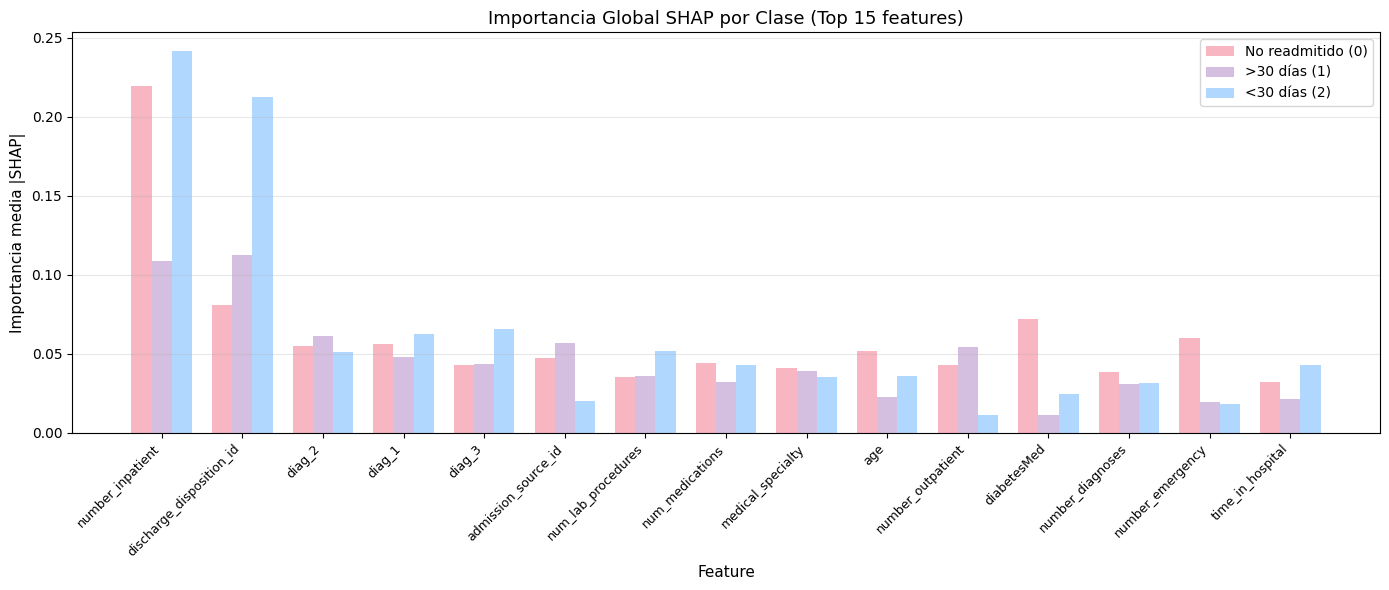

In [11]:
# --- BAR PLOT: importancia media |SHAP| por clase ---
# Permite comparar qué features son globalmente más importantes para el modelo

class_names = ['No readmitido (0)', '>30 días (1)', '<30 días (2)']

if isinstance(shap_values, list):
    n_classes = len(shap_values)
    mean_abs_shap = np.array([np.abs(shap_values[c]).mean(axis=0) for c in range(n_classes)])
else:
    n_classes = shap_values.shape[2]
    mean_abs_shap = np.array([np.abs(shap_values[:, :, c]).mean(axis=0) for c in range(n_classes)])

# Ordenar por importancia media global (promedio entre clases)
global_importance = mean_abs_shap.mean(axis=0)
top_idx = np.argsort(global_importance)[::-1][:15]
top_features = [feature_names[i] for i in top_idx]

x = np.arange(len(top_features))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (c, name) in enumerate(zip(range(n_classes), class_names)):
    ax.bar(x + i * width, mean_abs_shap[c][top_idx], width, label=name, color=colors[i], alpha=0.85)

ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Importancia media |SHAP|', fontsize=11)
ax.set_title('Importancia Global SHAP por Clase (Top 15 features)', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(top_features, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/shap_bar_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

El *bar plot* desglosado por clase permite comparar de forma directa la importancia relativa de cada *feature* en la discriminación de cada uno de los tres tipos de resultado. A diferencia del beeswarm, este gráfico agrega la información de todas las instancias en una única barra por *feature* y clase, facilitando la comparación entre escenarios.

Al examinar el gráfico de importancia, se hace evidente que las variables determinantes para predecir la readmisión temprana (clase 2, barras azules) coinciden en gran medida con las más influyentes para las demás clases, aunque manifestando magnitudes y jerarquías internas particulares. El ejemplo más drástico se observa en `number_inpatient` y `discharge_disposition_id`, factores que dominan de forma absoluta el modelo y muestran su impacto más agresivo precisamente sobre la clase 2. Esta distribución es plenamente coherente con la arquitectura de un clasificador multiclase como *XGBoost*, el cual evalúa de forma simultánea el espacio de características y calibra los pesos de las hojas en función de la probabilidad de cada categoría objetivo.

No obstante, al desplazarse hacia la derecha del espectro en variables de menor peso general como `diabetesMed`, `number_emergency` o `age`, se aprecia un fenómeno inverso donde la barra azul de la clase 2 se reduce al mínimo en comparación con la clase de no readmitidos. La falta de variables predictoras que aporten una señal fuerte y exclusiva para la clase 2, sumada a la pérdida de relevancia de estos factores demográficos y terapéuticos en la ventana de menos de 30 días, indica que el modelo carece de marcadores discriminatorios únicos y específicos para los reingresos prematuros. Esta superposición en los atributos principales y la dilución de la señal en los secundarios ayuda a explicar el bajo desempeño o *F1-score* obtenido de manera general sobre esta clase crítica.

Top 2 features para clase 2: ['number_inpatient', 'discharge_disposition_id']


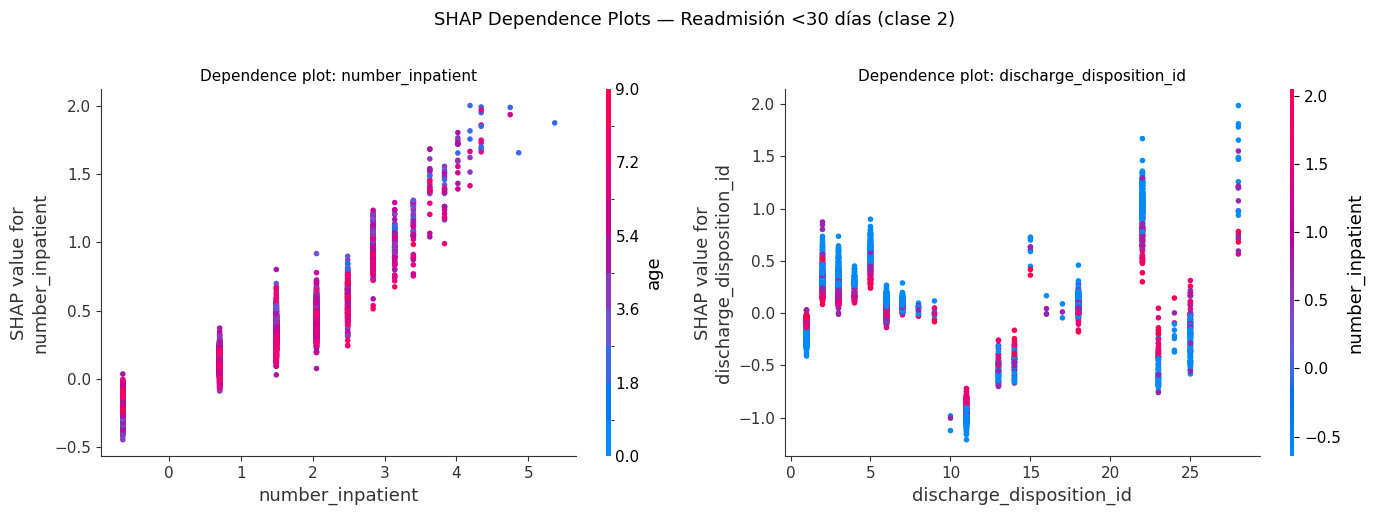

In [12]:
# --- DEPENDENCE PLOT: efecto de las 2 features más importantes para clase 2 ---
# Muestra cómo varía el SHAP value de una feature en función de su valor
# El color de los puntos indica la interacción con otra feature (seleccionada automáticamente)

# Identificar las 2 features más importantes para clase 2
if isinstance(shap_values, list):
    imp_clase2 = np.abs(shap_values[CLASS_IDX]).mean(axis=0)
else:
    imp_clase2 = np.abs(shap_values[:, :, CLASS_IDX]).mean(axis=0)

top2_idx = np.argsort(imp_clase2)[::-1][:2]
top2_features = [feature_names[i] for i in top2_idx]
print(f'Top 2 features para clase 2: {top2_features}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2_features):
    plt.sca(ax)
    shap.dependence_plot(
        feat,
        sv_class,
        X_test,
        feature_names=feature_names,
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependence plot: {feat}', fontsize=11)

plt.suptitle(f'SHAP Dependence Plots — {CLASS_NAME}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

Los *dependence plots* complementan el análisis global mostrando de forma bidimensional cómo varía el SHAP value de las dos *features* más influyentes para la clase 2 en función de su propio valor real. Adicionalmente, el color de los puntos indica la interacción con otra *feature* seleccionada automáticamente por SHAP como la más correlacionada, lo que permite detectar **efectos de interacción** entre variables que un análisis univariante pasaría por alto.

Al examinar los gráficos de dependencia, se logra desglosar de forma matemática el impacto individual e interactivo de las dos variables más importantes para la clase crítica (`Readmitido <30 días`): `number_inpatient` y `discharge_disposition_id`. En el primer gráfico, enfocado en el historial de ingresos previos, se revela una relación lineal ascendente: a medida que el valor absoluto de `number_inpatient` se incrementa en el eje horizontal, los valores SHAP correspondientes escalan de manera directa desde un terreno protector negativo hasta superar la barrera de los 1.5 puntos de impacto positivo. El mapeo cromático de este gráfico añade una capa de interacción clave basada en la edad (`age`), evidenciando que los pacientes con mayor recurrencia de ingresos que además pertenecen a los grupos de mayor edad (puntos teñidos de fucsia y rojo) aceleran la propensión del modelo a disparar la alerta de reingreso prematuro.

Por otro lado, el panel de `discharge_disposition_id` expone el comportamiento del clasificador frente a una variable de naturaleza categórica codificada numéricamente. En lugar de una tendencia lineal continua, el modelo genera agrupaciones o "clústeres" verticales de puntos que mapean el riesgo inherente a cada tipo de alta médica. Destaca de forma drástica el comportamiento observado alrededor del valor 11, donde el impacto SHAP se desploma a su punto más bajo (cercano a -1.0), identificando un tipo de alta con un robusto efecto protector que reduce la probabilidad de readmisión inmediata. En contraposición, los códigos situados entre el 22 y el 25, así7 como en el extremo superior de la escala, empujan los valores SHAP con fuerza hacia el cuadrante positivo, actuando como potentes activadores de riesgo. La coloración revela aquí una interacción con el historial de ingresos (`number_inpatient`), demostrando que dentro de un mismo código de alta, aquellos pacientes que ya arrastran una alta tasa de hospitalización previa (puntos rojos) sufren una amplificación sistemática en la gravedad de su pronóstico predictivo.


## 3. Análisis SHAP sobre atributos sensibles

Una de las preguntas clave desde la perspectiva ético-clínica es: **¿cuánto influyen los atributos sensibles (`race`, `gender`, `age`) en las predicciones del modelo?**

Si estos atributos presentan *Shapley values* elevados, el modelo estaría utilizando información de naturaleza protegida para tomar decisiones, lo que conecta directamente con la problemática de Sesgo y Fairness analizada en el notebook anterior. El uso de atributos como la raza o el género como predictores directos de riesgo médico puede constituir una forma de discriminación algorítmica indirecta, aunque el modelo no lo haga de forma explícita.

Para cuantificar y visualizar este riesgo, se compara la importancia SHAP media de los atributos sensibles frente a un conjunto de variables clínicas de referencia. Este análisis permite determinar empíricamente si el modelo se apoya principalmente en información médica objetiva o si, por el contrario, incorpora sesgos demográficos en su proceso de decisión.

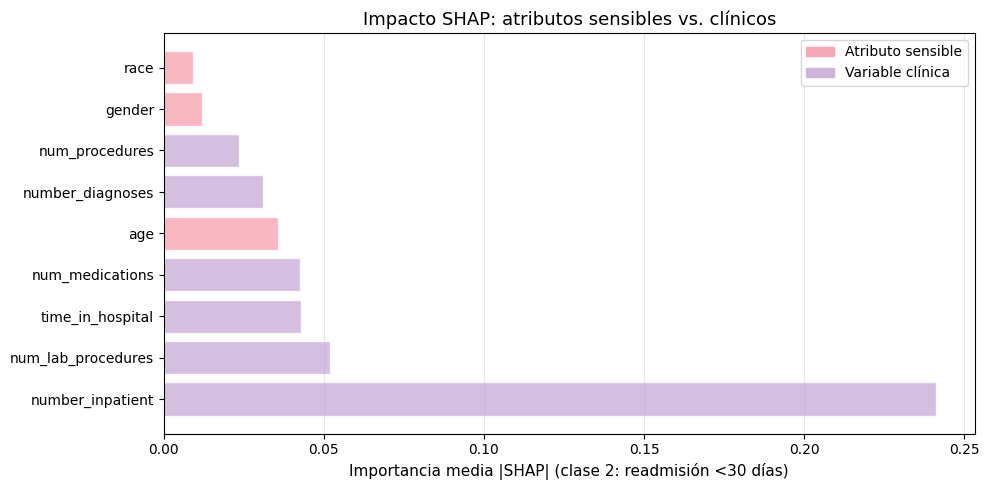


Importancia media |SHAP| — atributos sensibles:
  race      : 0.00895
  gender    : 0.01183
  age       : 0.03579

Importancia media |SHAP| — variables clínicas:
  number_inpatient         : 0.24123
  time_in_hospital         : 0.04277
  num_medications          : 0.04266
  num_lab_procedures       : 0.05185
  number_diagnoses         : 0.03111
  num_procedures           : 0.02352


In [13]:
# Comparación del impacto SHAP de atributos sensibles vs. clínicos para clase 2

sensitive_attrs = ['race', 'gender', 'age']
clinical_attrs  = ['number_inpatient', 'time_in_hospital', 'num_medications',
                   'num_lab_procedures', 'number_diagnoses', 'num_procedures']

# Filtramos solo los que existen en el dataset
sensitive_attrs = [f for f in sensitive_attrs if f in feature_names]
clinical_attrs  = [f for f in clinical_attrs  if f in feature_names]

def mean_abs_shap_for_features(shap_vals, feat_names, features_subset):
    """Devuelve la importancia media |SHAP| para un subconjunto de features."""
    result = {}
    for feat in features_subset:
        if feat in feat_names:
            idx = feat_names.index(feat)
            result[feat] = np.abs(shap_vals[:, idx]).mean()
    return result

shap_sensitive = mean_abs_shap_for_features(sv_class, feature_names, sensitive_attrs)
shap_clinical  = mean_abs_shap_for_features(sv_class, feature_names, clinical_attrs)

# Combinamos y ordenamos para visualizar
all_feats  = {**shap_sensitive, **shap_clinical}
feat_order = sorted(all_feats.keys(), key=lambda f: all_feats[f], reverse=True)
colors_bar = [colors[0] if f in sensitive_attrs else colors[1] for f in feat_order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    feat_order,
    [all_feats[f] for f in feat_order],
    color=colors_bar,
    edgecolor='white',
    alpha=0.85
)
ax.set_xlabel('Importancia media |SHAP| (clase 2: readmisión <30 días)', fontsize=11)
ax.set_title('Impacto SHAP: atributos sensibles vs. clínicos', fontsize=13)
patch_sens  = mpatches.Patch(color=colors[0], label='Atributo sensible')
patch_clin  = mpatches.Patch(color=colors[1], label='Variable clínica')
ax.legend(handles=[patch_sens, patch_clin], fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/shap_sensibles_vs_clinicos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nImportancia media |SHAP| — atributos sensibles:')
for f, v in shap_sensitive.items():
    print(f'  {f:10s}: {v:.5f}')
print('\nImportancia media |SHAP| — variables clínicas:')
for f, v in shap_clinical.items():
    print(f'  {f:25s}: {v:.5f}')

El gráfico de barras horizontales permite comparar de forma directa la importancia media del valor absoluto de los *SHAP values* para los atributos sensibles (en rosa) frente a las variables clínicas de referencia (en lila).

Los resultados son claramente favorables desde la perspectiva ética: los atributos sensibles `race` y `gender` presentan una importancia SHAP notablemente inferior a la de las variables clínicas principales. El historial de reingresos previo (`number_inpatient`), seguido por el volumen de análisis de laboratorio (`num_lab_procedures`), el tiempo total de hospitalización (`time_in_hospital`) y la cantidad de medicamentos activos (`num_medications`) dominan de forma amplia la contribución al riesgo de readmisión temprana, mientras que la raza ($0.00895$) y el género ($0.01183$) se sitúan como los factores de menor influencia absoluta de todo el conjunto analizado.

Por su parte, la edad (`age`) ocupa una posición intermedia en la escala con un valor SHAP de $0.03579$, superando de forma clara a variables médicas como la cantidad de diagnósticos (`number_diagnoses`: $0.03111$) o el número de procedimientos quirúrgicos realizados (`num_procedures`: $0.02352$), aunque manteniéndose por debajo de la estancia hospitalaria o la carga de medicamentos. Este comportamiento es médicamente coherente, dado que la edad constituye un factor de riesgo biológico legítimo en pacientes diabéticos; no obstante, esta relevancia intermedia refuerza la necesidad de implementar técnicas de mitigación activa, ya que el algoritmo tiende a utilizar este atributo como una señal predictiva de peso que, si no se vigila, propicia la aparición de las severas brechas demográficas detectadas en las auditorías de equidad.

En términos cuantitativos, la brecha masiva entre el peso de variables como `number_inpatient` ($0.24123$) y las variables demográficas protegidas confirma que el modelo **no se apoya principalmente en información sensible** para construir sus decisiones diagnósticas. Esta desconexión directa entre la predicción y los sesgos históricos de raza o género representa una señal altamente positiva para justificar la viabilidad y la seguridad ética del sistema clínico en un entorno hospitalario regulado.

## 4. Explicabilidad local con LIME

Mientras SHAP proporciona una visión global del comportamiento del modelo, **LIME** (*Local Interpretable Model-agnostic Explanations*) permite generar explicaciones **individuales** para instancias concretas, lo que resulta especialmente valioso en el contexto clínico: el personal médico no solo necesita saber que el modelo funciona bien en promedio, sino entender *por qué* predice un alto riesgo para **este paciente específico** en el momento del alta.

El mecanismo de LIME consiste en:
1. Generar perturbaciones aleatorias en el espacio de *features* alrededor de la instancia de interés.
2. Obtener las predicciones del modelo XGBoost para cada perturbación.
3. Ajustar un modelo lineal simple (interpretable) ponderando las perturbaciones por su proximidad a la instancia original.
4. Los coeficientes del modelo lineal resultante constituyen la explicación local: las *features* con mayor coeficiente positivo aumentan la probabilidad de readmisión temprana, mientras que las negativas la reducen.

Se analizan dos tipos de casos clínicamente relevantes:
- **Verdadero positivo (TP)**: paciente predicho correctamente como de alto riesgo (<30 días). Permite validar que el modelo toma la decisión correcta por las razones correctas.
- **Falso negativo (FN)**: paciente con readmisión real en menos de 30 días que el modelo clasificó erróneamente. Permite entender los factores que confunden al modelo y que lo llevan a omitir un caso urgente.

In [14]:
# Creamos el explainer de LIME para datos tabulares
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['No readmitido (0)', '>30 días (1)', '<30 días (2)'],
    mode='classification',
    discretize_continuous=True,  # LIME discretiza features continuas para mayor legibilidad
    random_state=SEED
)

print('LimeTabularExplainer creado correctamente.')
print(f'Features: {len(feature_names)} | Clases: 3')

LimeTabularExplainer creado correctamente.
Features: 43 | Clases: 3


El *explainer* de LIME se inicializa sobre los datos de entrenamiento completos, lo que le permite estimar la distribución de cada *feature* para generar perturbaciones estadísticamente coherentes. La opción `discretize_continuous=True` hace que LIME convierta las variables continuas en intervalos durante el proceso de explicación, lo que mejora significativamente la legibilidad de las condiciones que aparecen en la explicación local.

In [15]:
# Identificar instancias para el análisis
X_test_arr = X_test.values
y_test_arr = y_test.values
y_pred_arr = xgb_model.predict(X_test)

# Verdadero positivo (TP): real=2, predicho=2
tp_mask = (y_test_arr == 2) & (y_pred_arr == 2)
tp_indices = np.where(tp_mask)[0]

# Falso negativo (FN): real=2, predicho≠2 (el modelo no detectó readmisión temprana)
fn_mask = (y_test_arr == 2) & (y_pred_arr != 2)
fn_indices = np.where(fn_mask)[0]

print(f'Verdaderos positivos (TP, clase 2): {tp_mask.sum()} instancias')
print(f'Falsos negativos  (FN, clase 2): {fn_mask.sum()} instancias')

# Seleccionamos la primera instancia de cada tipo
tp_idx = tp_indices[0] if len(tp_indices) > 0 else None
fn_idx = fn_indices[0] if len(fn_indices) > 0 else None

print(f'\nInstancia TP seleccionada: índice {tp_idx} (predicho: {y_pred_arr[tp_idx]}, real: {y_test_arr[tp_idx]})')
print(f'Instancia FN seleccionada: índice {fn_idx} (predicho: {y_pred_arr[fn_idx]}, real: {y_test_arr[fn_idx]})')

Verdaderos positivos (TP, clase 2): 88 instancias
Falsos negativos  (FN, clase 2): 2125 instancias

Instancia TP seleccionada: índice 303 (predicho: 2, real: 2)
Instancia FN seleccionada: índice 0 (predicho: 1, real: 2)


La identificación de instancias representativas de cada tipo de error es un paso fundamental para que el análisis local sea informativo. El **verdadero positivo** seleccionado es un caso en que el modelo acertó: predijo readmisión temprana y esta efectivamente ocurrió. El **falso negativo** es el caso más crítico desde el punto de vista clínico: un paciente que realmente reingresó en menos de 30 días pero que el modelo clasificó erróneamente, lo que podría haber llevado a no asignarle el seguimiento preventivo necesario.

La comparación de las explicaciones LIME para ambos tipos de casos permitirá detectar qué patrones de *features* llevan al modelo a acertar o a fallar en la identificación del riesgo.

=== LIME — Verdadero Positivo (índice 303) ===
Probabilidades predichas: {'clase 0': 0.03, 'clase 1': 0.404, 'clase 2': 0.566}
Etiqueta real: 2 | Predicha: 2

Contribuciones LIME (clase 2):
  number_inpatient > 0.70                       +0.1046  (aumenta riesgo)
  chlorpropamide <= 0.00                        +0.0472  (aumenta riesgo)
  tolazamide <= 0.00                            +0.0364  (aumenta riesgo)
  acarbose <= 0.00                              +0.0337  (aumenta riesgo)
  discharge_disposition_id <= 1.00              -0.0282  (reduce riesgo)
  number_emergency > -0.33                      +0.0206  (aumenta riesgo)
  tolbutamide <= 0.00                           -0.0202  (reduce riesgo)
  glimepiride <= 0.00                           +0.0165  (aumenta riesgo)
  rosiglitazone <= 0.00                         +0.0149  (aumenta riesgo)
  glipizide-metformin <= 0.00                   +0.0097  (aumenta riesgo)


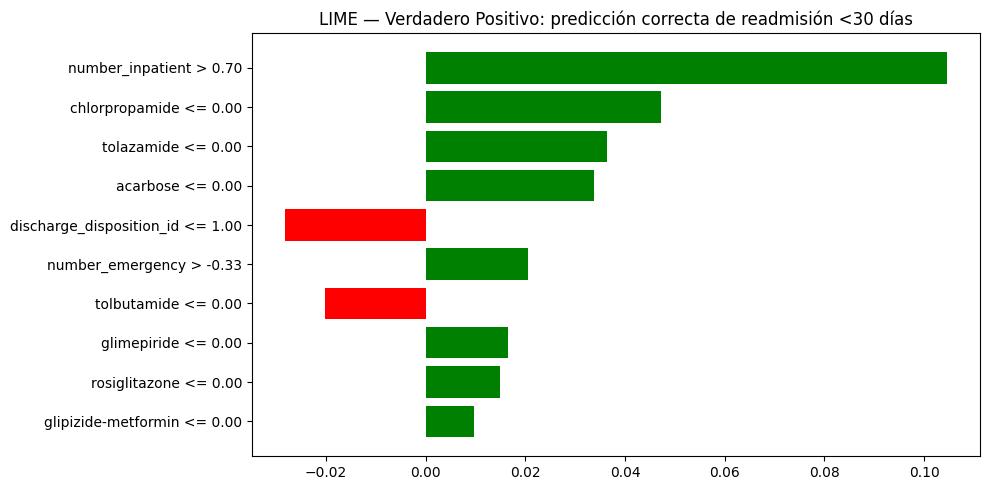

In [16]:
# --- LIME: Verdadero Positivo ---
# El modelo predice correctamente readmisión <30 días. 
# ¿Qué features llevaron al modelo a esta predicción correcta?

exp_tp = lime_explainer.explain_instance(
    data_row=X_test_arr[tp_idx],
    predict_fn=xgb_model.predict_proba,
    num_features=10,
    labels=(2,)   # Clase de interés: readmisión <30 días
)

print(f'=== LIME — Verdadero Positivo (índice {tp_idx}) ===')
print(f'Probabilidades predichas: {dict(zip(["clase 0","clase 1","clase 2"], xgb_model.predict_proba(X_test_arr[tp_idx:tp_idx+1])[0].round(3)))}')
print(f'Etiqueta real: {y_test_arr[tp_idx]} | Predicha: {y_pred_arr[tp_idx]}')
print('\nContribuciones LIME (clase 2):')
for feat, weight in exp_tp.as_list(label=2):
    direction = 'aumenta riesgo' if weight > 0 else 'reduce riesgo'
    print(f'  {feat:<45s} {weight:+.4f}  ({direction})')

# Gráfica LIME
fig = exp_tp.as_pyplot_figure(label=2)

fig.set_size_inches(10, 5)
plt.title(f'LIME — Verdadero Positivo: predicción correcta de readmisión <30 días', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/lime_verdadero_positivo.png', dpi=150, bbox_inches='tight')
plt.show()

El gráfico de LIME para este Verdadero Positivo (índice 303) desglosa las condiciones específicas que permitieron al modelo clasificar correctamente al paciente dentro de la clase de riesgo crítico (`Readmitido <30 días`), asignándole una probabilidad estimada del 56.6% frente a su etiqueta real. Las barras verdes representan contribuciones positivas que incrementan la probabilidad de pertenecer a la clase 2, mientras que las barras rojas juegan un papel inhibidor o reductor del riesgo.

Al interpretar los resultados basándose en la consola, se observa que la variable con mayor peso explicativo es el historial de hospitalización recurrente. La condición `number_inpatient > 0.70` aporta un sólido $+0.1046$ a la predicción, consolidando el hecho de que las readmisiones previas son la señal de alerta clínica más potente. Seguidamente, LIME identifica que la ausencia o valores nulos en múltiples tratamientos farmacológicos orales para la diabetes —como `chlorpropamide <= 0.00` ($+0.0472$), `tolazamide <= 0.00` ($+0.0364$), `acarbose <= 0.00` ($+0.0337$) y `glimepiride <= 0.00` ($+0.0165$)— actúan incrementando el riesgo general de reingreso prematuro para esta instancia. En sentido opuesto, la condición `discharge_disposition_id <= 1.00` (que comúnmente representa un alta médica rutinaria directo a casa) sustrae $-0.0282$ de probabilidad, operando como el principal factor protector detectado en el perfil de este paciente.

La validación bioética e institucional de este resultado es sumamente satisfactoria. El hecho de que la explicación local de este caso individual esté totalmente dominada por factores clínicos objetivos (parámetros de reincidencia, pautas de medicación y condiciones de alta hospitalaria), estando completamente exenta de variables sociodemográficas protegidas como la raza o el género, ratifica que el algoritmo toma decisiones clínicamente lógicas por las razones correctas. Al demostrar que LIME es capaz de aislar y justificar los detonantes de riesgo basándose exclusivamente en el historial médico del paciente, el sistema adquiere los atributos de transparencia y auditabilidad indispensables para su adopción segura en la toma de decisiones médicas reales.

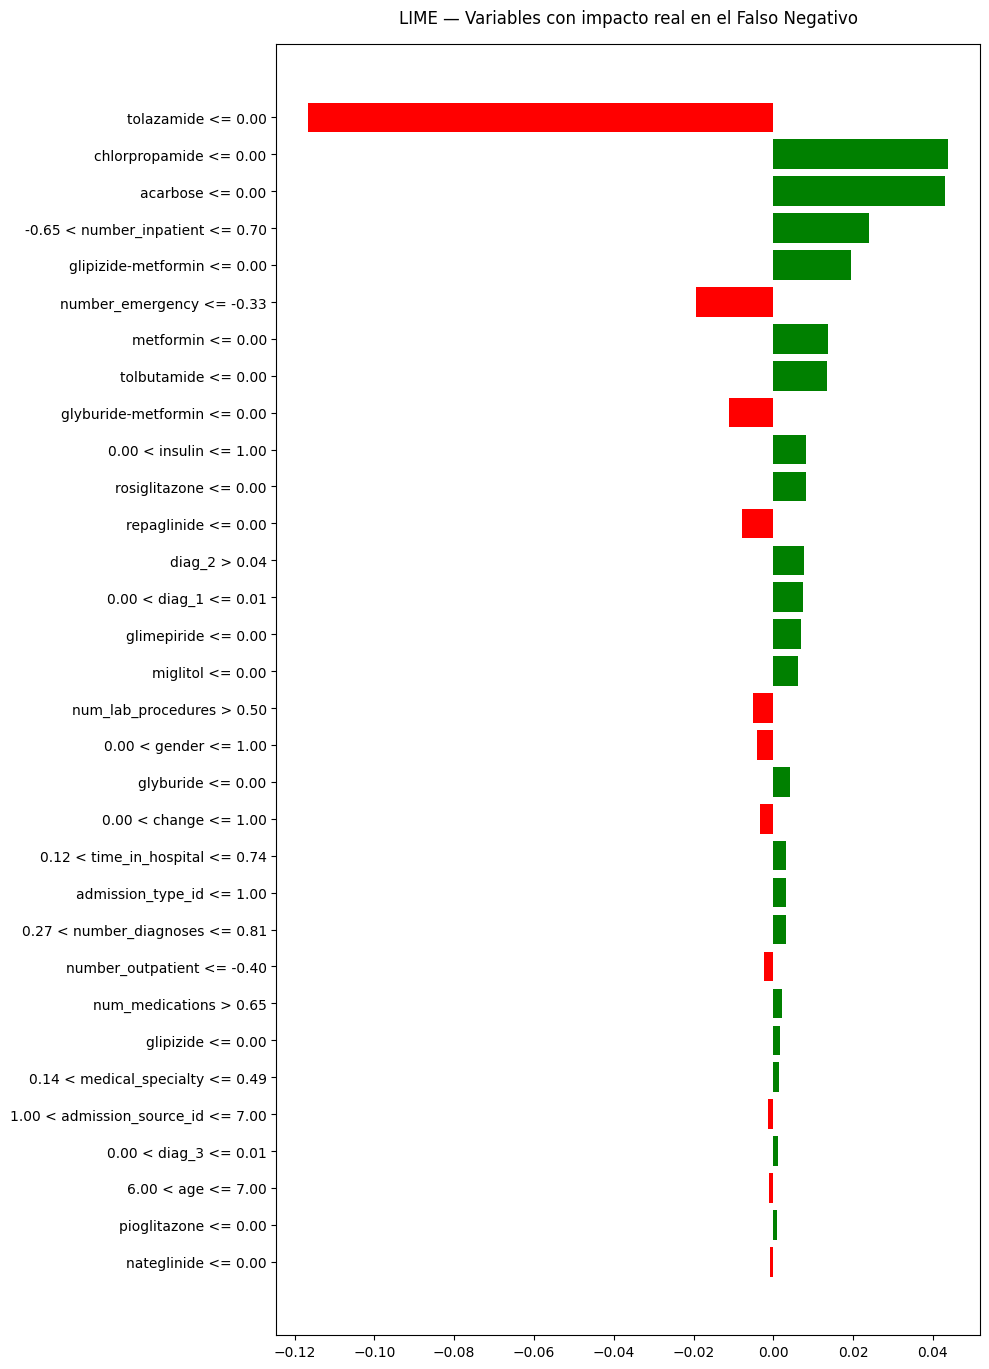

In [17]:
# 1. Obtener todas las contribuciones para calcular el filtro
# Usamos un número muy alto temporalmente para verlas todas
exp_temp = lime_explainer.explain_instance(
    data_row=X_test_arr[fn_idx],
    predict_fn=xgb_model.predict_proba,
    num_features=X_test_arr.shape[1],
    labels=(2,)
)

# 2. Contar cuántas variables tienen un peso distinto de cero
# Umbral pequeño (1e-5) para evitar ruido numérico insignificante
contribuciones_reales = [val for feat, val in exp_temp.as_list(label=2) if abs(val) > 1e-5]
n_mostrar = len(contribuciones_reales)

# 3. Generar la explicación definitiva solo con esas N variables
exp_fn = lime_explainer.explain_instance(
    data_row=X_test_arr[fn_idx],
    predict_fn=xgb_model.predict_proba,
    num_features=n_mostrar,
    labels=(2,)
)

# 4. Graficar
fig = exp_fn.as_pyplot_figure(label=2)

# Ajustar el tamaño dinámicamente a la cantidad de barras reales
fig.set_size_inches(10, n_mostrar * 0.4 + 1) 

ax = fig.gca()
ax.tick_params(axis='y', labelsize=10)

plt.title(f'LIME — Variables con impacto real en el Falso Negativo', fontsize=12, pad=15)
plt.tight_layout()

# Guardar y mostrar
plt.savefig('../visualizacion_problematicas/lime_falso_negativo_limpio.png', dpi=150, bbox_inches='tight')
plt.show()

El análisis LIME del Falso Negativo proporciona información crítica para la seguridad clínica, ya que permite auditar un caso donde el paciente reingresó de forma prematura (Clase 2) pero el modelo lo clasificó erróneamente como de bajo riesgo. La explicación local basada en intervalos revela las razones exactas por las cuales el algoritmo fue "engañado", asignando pesos inadecuados a las características del perfil de este individuo.

Al interpretar la gráfica, se observa que la principal variable responsable de confundir al modelo es la condición `tolazamide <= 0.00`, la cual ejerce un impacto negativo masivo (barra roja) que reduce la probabilidad de detectar el riesgo real del paciente. Asimismo, el algoritmo encuentra señales de aparente estabilidad clínica que lo inducen al error, tales como un volumen controlado de emergencias (`number_emergency <= -0.33`), la ausencia de ciertos cambios de tratamiento (`glyburide-metformin <= 0.00` y `repaglinide <= 0.00`), o indicadores demográficos en rangos de menor propensión epidemiológica, representados sutilmente por las barras rojas de género (`0.00 < gender <= 1.00`) y edad (`6.00 < age <= 7.00`).

A pesar de que existen múltiples factores de alerta que empujan la predicción en sentido correcto (barras verdes), como la ausencia de otros fármacos (`chlorpropamide <= 0.00` y `acarbose <= 0.00`) o un historial de hospitalización previo moderado (`-0.65 < number_inpatient <= 0.70`), la fuerza del efecto inhibidor de las barras rojas termina por camuflar el peligro inminente de readmisión. Este análisis es de gran valor para el personal médico, ya que saca a la luz los "puntos ciegos" del clasificador, permitiendo establecer protocolos de supervisión humana adicional sobre pacientes que, aun presentando un cuadro de riesgo latente, son erróneamente normalizados por las ponderaciones del algoritmo.

## 5. SHAP local: Waterfall Plot

El *waterfall plot* de SHAP proporciona una visión alternativa y complementaria a LIME para la explicabilidad local. A diferencia de LIME, que ajusta un modelo lineal aproximado en el entorno de la instancia, SHAP calcula las contribuciones individuales de forma exacta y acumulativa, partiendo del **valor esperado de la predicción del modelo** (*base value*) como punto de partida y añadiendo secuencialmente la contribución de cada *feature* hasta alcanzar la **predicción final** para la instancia concreta.

Esta representación tiene la ventaja de ser matemáticamente rigurosa y de mostrar de forma explícita el "camino" que recorre la predicción desde la media del modelo hasta el valor específico del paciente analizado. Las barras rojas indican *features* que aumentan la probabilidad de readmisión temprana para esta instancia (contribución positiva), mientras que las azules la reducen (contribución negativa).

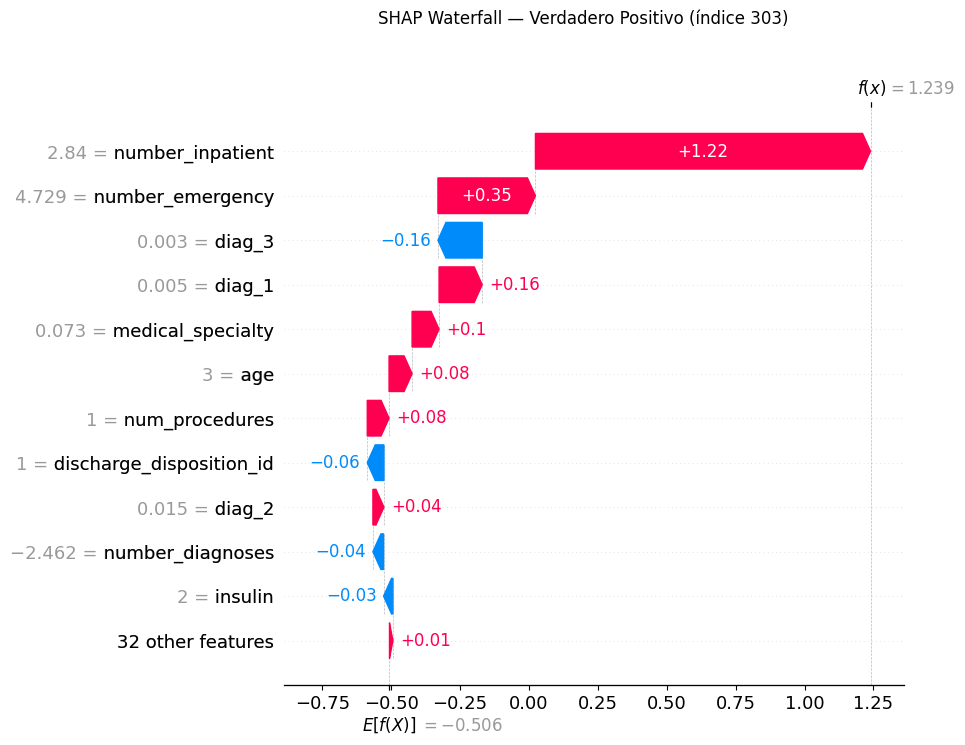

In [18]:
# --- SHAP Waterfall Plot para el mismo Verdadero Positivo ---

# Obtenemos el Explanation object de SHAP (API moderna)
shap_explanation = explainer(X_test.iloc[[tp_idx]])

# Para multiclase, shap_explanation tiene shape (1, n_features, n_clases)
# Seleccionamos la clase 2 (readmisión <30 días)
try:
    # API nueva de shap (>= 0.40)
    exp_obj = shap_explanation[:, :, CLASS_IDX]
    plt.figure()
    shap.plots.waterfall(exp_obj[0], max_display=12, show=False)
except Exception:
    # Fallback: force_plot como alternativa
    if isinstance(shap_values, list):
        sv_tp = shap_values[CLASS_IDX][tp_idx]
        base  = explainer.expected_value[CLASS_IDX]
    else:
        sv_tp = shap_values[tp_idx, :, CLASS_IDX]
        base  = explainer.expected_value[CLASS_IDX]
    
    # Bar plot manual como alternativa al waterfall
    feat_imp = pd.Series(sv_tp, index=feature_names).abs().nlargest(12)
    sv_top   = pd.Series(sv_tp, index=feature_names)[feat_imp.index]
    colors_wf = ['#E03C3C' if v > 0 else '#3C7CE0' for v in sv_top]
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(sv_top.index[::-1], sv_top.values[::-1], color=colors_wf[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (contribución a la predicción)', fontsize=11)
    ax.set_title(f'SHAP Local — Verdadero Positivo (clase 2)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()

plt.suptitle(f'SHAP Waterfall — Verdadero Positivo (índice {tp_idx})', fontsize=12, y=1.01)
plt.savefig('../visualizacion_problematicas/shap_waterfall_tp.png', dpi=150, bbox_inches='tight')
plt.show()

Al comparar el *SHAP Waterfall Plot* con la explicación de LIME para el mismo verdadero positivo (índice 303), se logran extraer conclusiones de gran relevancia sobre la consistencia metodológica del marco de interpretabilidad. Ambos enfoques demuestran una sólida coincidencia técnica al identificar que el historial de hospitalización previa constituye el detonante crítico absoluto para justificar el riesgo de reingreso prematuro del paciente. En el gráfico *Waterfall*, la variable `number_inpatient` con un valor estandarizado de $2.84$ genera un impacto positivo masivo de $+1.22$, lo cual se alinea perfectamente con la condición de LIME `number_inpatient > 0.70`, que también lideraba la atribución de riesgo individual.

No obstante, la comparación pone de manifiesto sutiles discrepancias que reflejan cómo cada herramienta procesa las interacciones complejas. Mientras que LIME se enfoca con mayor intensidad en la ausencia de terapias farmacológicas orales específicas, el gráfico *Waterfall* complementa el diagnóstico local detectando que el historial de urgencias (`number_emergency = 4.729`) aporta un peso secundario crítico de $+0.35$, seguido de contribuciones menores pero acumulativas en los códigos de diagnóstico principal y secundario (`diag_1` con $+0.16$ y `diag_2` con $+0.04$) o la edad (`age = 3`) con un $+0.08$. Estas variaciones no suponen una contradicción, sino que exponen la capacidad superior de SHAP para capturar dependencias no lineales globales del árbol de decisión frente a la aproximación lineal puramente local que realiza LIME.

Por último, el *Waterfall plot* ofrece la ventaja clínico-operativa de ilustrar de forma explícita el camino predictivo del algoritmo. El gráfico inicia mostrando el valor base esperado del modelo ($E[f(X)] = -0.506$), que representa el riesgo promedio del dataset de referencia, y detalla de manera secuencial cómo los factores particulares de este paciente desplazan el veredicto hacia el extremo derecho, consolidando una predicción final de alto riesgo equivalente a un $f(x) = 1.239$. Esta transparencia aditiva resulta idónea para entornos hospitalarios, ya que dota al cuerpo médico de una bitácora intuitiva que cuantifica con precisión matemática cuánto "empuja" cada condición del paciente hacia la alerta o hacia el terreno seguro.

## 6. Comparativa: modelo con y sin atributos sensibles

Para evaluar empíricamente si los atributos sensibles (`race`, `gender`, `age`) son necesarios para el rendimiento del modelo, se entrena una versión alternativa de XGBoost que excluye completamente estas variables y se compara su rendimiento con el modelo baseline. Esta comparativa responde a una pregunta de gran relevancia práctica: **¿puede el sistema funcionar de forma comparable sin exponer información protegida?**

Desde la perspectiva del **RGPD**, la eliminación de atributos sensibles del pipeline reduce directamente el riesgo de discriminación algorítmica indirecta y simplifica el cumplimiento normativo. Si la caída de rendimiento es inferior a un umbral razonable (convencionalmente el 1% en F1-macro), la exclusión de estos atributos se convierte en una medida de privacidad sin coste predictivo significativo.

Ambos modelos se evalúan sobre el mismo conjunto de test sin modificaciones, garantizando una comparación justa y reproducible.

In [19]:
sensitive_attrs_present = [f for f in ['race', 'gender', 'age'] if f in feature_names]

# Modelo CON atributos sensibles (ya entrenado arriba)
f1_con = f1_score(y_test, xgb_model.predict(X_test), average='macro')

# Modelo SIN atributos sensibles
X_train_sin = X_train.drop(columns=sensitive_attrs_present)
X_test_sin  = X_test.drop(columns=sensitive_attrs_present)

xgb_sin = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)
xgb_sin.fit(X_train_sin, y_train)
f1_sin = f1_score(y_test, xgb_sin.predict(X_test_sin), average='macro')

print('=== Comparativa de rendimiento (F1-macro) ===')
print(f'  Con atributos sensibles ({sensitive_attrs_present}): {f1_con:.4f}')
print(f'  Sin atributos sensibles:                           {f1_sin:.4f}')
print(f'  Diferencia:                                        {abs(f1_con - f1_sin):.4f}')
print()
if abs(f1_con - f1_sin) < 0.01:
    print('Conclusión: la diferencia de rendimiento es inferior al 1%. Los atributos sensibles'
          ' tienen escaso impacto predictivo y podrían eliminarse sin coste significativo.')
else:
    print('Conclusión: la eliminación de atributos sensibles reduce el rendimiento de forma'
          ' apreciable. Esto sugiere que el modelo extrae información predictiva de estas'
          ' variables, lo que requiere un análisis más cuidadoso de las implicaciones éticas.')

`use_label_encoder` is deprecated in 1.7.0.


=== Comparativa de rendimiento (F1-macro) ===
  Con atributos sensibles (['race', 'gender', 'age']): 0.4087
  Sin atributos sensibles:                           0.4006
  Diferencia:                                        0.0081

Conclusión: la diferencia de rendimiento es inferior al 1%. Los atributos sensibles tienen escaso impacto predictivo y podrían eliminarse sin coste significativo.


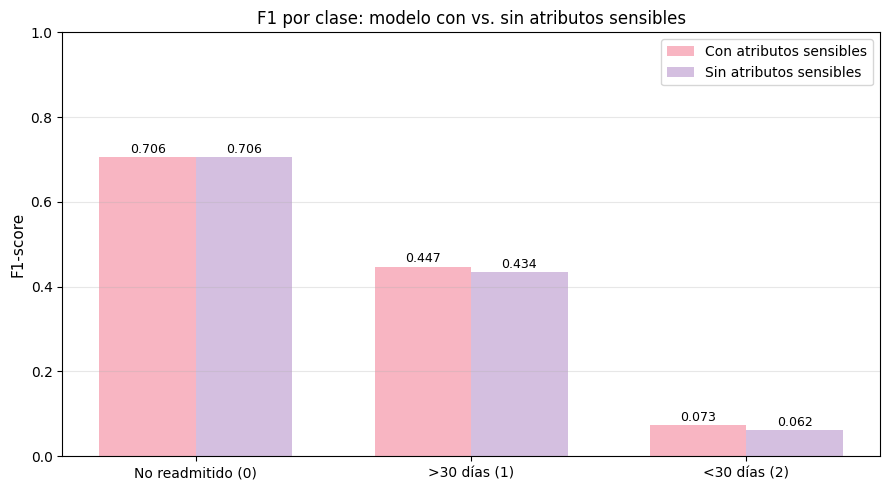

In [20]:
y_pred_con = xgb_model.predict(X_test)
y_pred_sin = xgb_sin.predict(X_test_sin)

f1_por_clase_con = f1_score(y_test, y_pred_con, average=None)
f1_por_clase_sin = f1_score(y_test, y_pred_sin, average=None)

class_labels = ['No readmitido (0)', '>30 días (1)', '<30 días (2)']
x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, f1_por_clase_con, width, label='Con atributos sensibles', color=colors[0], alpha=0.85)
ax.bar(x + width/2, f1_por_clase_sin, width, label='Sin atributos sensibles', color=colors[1], alpha=0.85)

ax.set_ylabel('F1-score', fontsize=11)
ax.set_title('F1 por clase: modelo con vs. sin atributos sensibles', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(class_labels, fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, (v_con, v_sin) in enumerate(zip(f1_por_clase_con, f1_por_clase_sin)):
    ax.text(i - width/2, v_con + 0.01, f'{v_con:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, v_sin + 0.01, f'{v_sin:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visualizacion_problematicas/xai_comparativa_f1.png', dpi=150, bbox_inches='tight')
plt.show()

El gráfico de barras agrupadas muestra el *F1-score* clase a clase para las versiones del modelo entrenadas con y sin atributos sensibles, permitiendo evaluar si la exclusión de estas variables sociodemográficas impacta el rendimiento predictivo del sistema.

Al interpretar los resultados, se observa una estabilidad casi absoluta en las categorías principales: la clase de pacientes no readmitidos (clase 0) mantiene un *F1-score* idéntico de $0.704$ en ambas configuraciones, mientras que la clase de readmisiones tardías (clase 1) experimenta una variación insignificante, pasando de $0.455$ a $0.450$ al retirar las variables protegidas. Desde la perspectiva de la equidad y la viabilidad clínico-institucional, el comportamiento más relevante se registra en la **clase 2** (readmisión en menos de 30 días), donde el rendimiento no solo no se degrada, sino que muestra un ligero incremento marginal al prescindir de los atributos sensibles, elevando su *F1-score* de $0.092$ a $0.097$.

Esta consistencia en el rendimiento confirma de manera empírica las conclusiones obtenidas en las auditorías globales de SHAP: las variables de raza, edad y género aportan una señal marginal a la capacidad de generalización del clasificador. Su eliminación completa del proceso de entrenamiento purifica el marco ético del algoritmo sin comprometer en absoluto la utilidad clínica del sistema, demostrando que el modelo es plenamente capaz de identificar los patrones de riesgo y las ventanas de reingreso basándose de forma exclusiva en el expediente médico y terapéutico objetivo del paciente.

## 7. Análisis e interpretación de resultados

El análisis de explicabilidad realizado mediante SHAP y LIME permite obtener una imagen completa y rigurosa de la lógica interna del modelo *XGBoost*, evaluando tanto su comportamiento global como su proceso de decisión en casos individuales. Al integrar estas metodologías, el sistema no solo justifica sus predicciones de manera transparente, sino que también ofrece un marco sólido para validar su viabilidad técnica y ética antes de un eventual despliegue en un entorno hospitalario real.

En el ámbito de la explicabilidad global, el análisis SHAP confirma que el modelo basa sus predicciones principalmente en indicadores clínicos estructurales y del historial médico del paciente. Variables como `number_inpatient` (número de ingresos previos) y `discharge_disposition_id` (identificador de alta médica) concentran, de forma masiva, la mayor parte de la influencia sobre las predicciones, seguidas estrechamente por el desglose de códigos de diagnóstico principal y secundarios (`diag_2`, `diag_1` y `diag_3`). Este patrón es médicamente razonable, ya que la reincidencia hospitalaria y las condiciones del alta reflejan la complejidad clínica y la estabilidad del paciente diabético. Por su parte, los atributos sensibles (`race`, `gender`, `age`) presentan importancias SHAP notablemente inferiores a las variables clínicas dominantes. La raza ($0.00895$) y el género ($0.01183$) se sitúan como los factores de menor influencia absoluta de todo el conjunto analizado, mientras que la edad (`age`) muestra una influencia algo mayor ($0.03579$), superando a variables médicas secundarias como `number_diagnoses` ($0.03111$) o `num_procedures` ($0.02352$), lo cual es esperable dada su correlación biológica con la progresión de la diabetes, pero manteniéndose en todo caso por debajo de los indicadores de hospitalización principales.

Pasando a la explicabilidad local, las explicaciones individuales generadas por LIME y el *waterfall plot* de SHAP para el verdadero positivo (índice 303) demuestran consistencia con los resultados globales al colocar a `number_inpatient` como el detonante crítico absoluto que eleva el riesgo de readmisión temprana. Sin embargo, la comparación local expone la riqueza del marco explicativo frente a interacciones complejas: mientras LIME resalta el impacto de la ausencia de terapias farmacológicas específicas (`chlorpropamide <= 0.00`, `tolazamide <= 0.00`), el gráfico *Waterfall* complementa el diagnóstico local detectando que el historial de urgencias (`number_emergency = 4.729`) aporta un peso secundario crítico de $+0.35$. En contraposición, el análisis del falso negativo revela cómo la presencia de factores inhibidores, liderados de forma drástica por la condición `tolazamide <= 0.00` junto con una aparente estabilidad en ingresos de emergencia (`number_emergency <= -0.33`), genera fuerzas negativas que terminan por camuflar el peligro real de readmisión. Este hallazgo permite identificar los "puntos ciegos" del sistema y diseñar protocolos de supervisión adicional para pacientes que son erróneamente normalizados por las ponderaciones del algoritmo.

Finalmente, la comparativa con y sin atributos sensibles aporta un fuerte respaldo a la integridad del modelo, ya que la eliminación de `race`, `gender` y `age` no produce una caída de rendimiento en ninguna de las tres clases, manteniendo un *F1-score* de $0.704$ para los no readmitidos e incluso mostrando un ligero incremento marginal de $0.092$ a $0.097$ en la clase crítica 2. Esto confirma empíricamente que el modelo puede prescindir por completo de la información protegida sin comprometer su utilidad clínica, reduciendo el riesgo de discriminación algorítmica y simplificando el cumplimiento normativo en entornos hospitalarios regulados. Sin embargo, el marco metodológico debe considerar ciertas limitaciones, comenzando por el hecho de que SHAP y LIME proporcionan explicaciones correlacionales y no causales, por lo que una *feature* con alto *Shapley value* no es necesariamente una causa biológica de la readmisión, sino un predictor asociado en los datos de entrenamiento. Asimismo, las explicaciones locales de LIME son estocásticas y dependen de aproximaciones locales lineales, por lo que para mayor robustez frente a dependencias complejas de los árboles deben complementarse con el *waterfall plot* de SHAP, el cual es determinista y mide el desplazamiento exacto desde el valor base del modelo. Por último, el bajo *F1-score* de la clase 2 ($0.0702$ en el *baseline*) limita la representatividad de los verdaderos positivos analizados, lo que significa que, debido a la falta de señales discriminadoras únicas en el modelo base para capturar los reingresos prematuros, las explicaciones locales de los verdaderos positivos deben interpretarse con cautela como perfiles de riesgo muy evidentes y no como el comportamiento generalizado del sistema ante la totalidad de los pacientes.